# 1D Прототип
Реализация одномерной задачи рассеияния гауссова пакета на прямоугольном потенциале для отладки метода решения

## Импорты

In [1]:
import numpy as np

from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve

import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Константы и условие

In [2]:
# Параметры системы
length = 40.0  # длина системы
N = 2000  # дискретизация
T = 20  # общее время симуляции
hbar = 1.0  # пост. Дирака

# Параметры пакета
m = 1.0  # масса
sigma = 1.0  # ширина
x0 = -10.0  # положение
k0 = 2.0  # импульс
x = np.linspace(-length / 2, length / 2, N)
norm = (2 * np.pi * sigma ** 2) ** (-0.25)

# Дифференциалы
dx = x[1] - x[0]
dt = 0.1 * dx ** 2

# Волновой пакет
psi = norm * np.exp(-(x - x0) ** 2 / (4 * sigma ** 2)) * np.exp(1j * k0 * x)

# Потенциал
a = 2.0  # ширина
V0 = 3  # высота
V = np.where(abs(x) < a, V0, 0.0)

## Реализация матриц Кранка - Николсон

### Решаемое уравнение
Уравнение __Шрёдингера__ ($\hbar=1, m=1$):
$$\frac{\partial \psi}{\partial t} = \left(-\frac{1}{2}\frac{\partial^2}{\partial x^2} + V(r)\right)\psi$$

Оно же через постоянную оператор гамильтониана $\hat{H}$:
$$\frac{\partial \psi}{\partial t} = -i \hat{H} \psi$$

На границах области $x=\pm L/2$ накладываем условие полного отражения $\psi=0$, что эквивалентно бесконечно высоким стенкам потенциала. После дискретизации на сетке оператор $\hat{H}$ переходит в матрицу $H \in \mathbb{C}^{N \times N}$ (спектр такого оператора __дискретен__ в силу конечности отрезка и граничных условий).
$$\frac{\partial \psi}{\partial t} = -i H \psi$$

### Схема Кранка - Николсона
$$\frac{\psi_i^{n+1} - \psi_i^n}{\Delta t} = -i H \frac{\psi_i^{n+1} + \psi_i^n}{2}$$

После приведения:
$$\underbrace{\left(I + \frac{i\Delta t}{2}H\right)}_{A}\psi^{n+1} = \underbrace{\left(I - \frac{i\Delta t}{2}H\right)}_{B}\psi^n$$

Заметим, что для одномерного случая матрица $H$ может быть представлена трёхдиагональной:
$$\hat{H} = -\frac{1}{2} \frac{\partial^2}{\partial x^2} + V(x)$$
После применения трёхточечной аппроксимации:
$$\left.\frac{\partial^2}{\partial x^2}\right|_{x_i} \approx \frac{\psi_{i-1} - 2\psi_i + \psi_{i+1}}{\Delta x^2}$$

А потому решается методом прогонки за $\mathcal{O}(n)$.

In [3]:
main_diag = np.ones(N) / dx ** 2 + V
side_diag = - 0.5 * np.ones(N - 1) / dx ** 2

H = diags([side_diag, main_diag, side_diag], [-1, 0, 1])

I = eye(N)
A = (I + 1j * dt * H / 2).tocsc()
B = (I - 1j * dt * H / 2).tocsc()

### Раскадровка

In [4]:
steps = int(T / dt)
save_every = steps // 200

In [5]:
frames = []

for n in range(steps):
    psi = spsolve(A, B @ psi)
    psi[0] = psi[-1] = 0.0
    if n % save_every == 0:
        frames.append(np.abs(psi)**2)

## Анимация

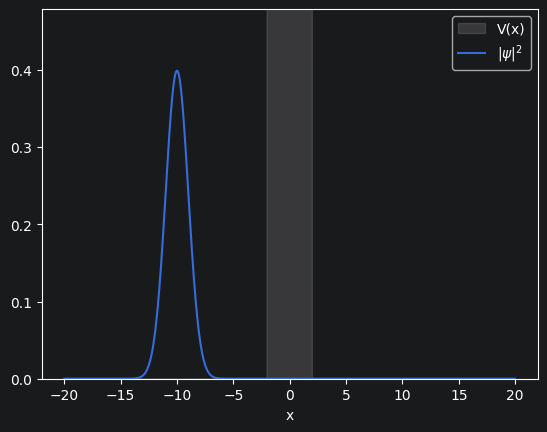

In [8]:
fig, ax = plt.subplots()

ax.fill_between(x, 0, V, alpha=0.3, color='gray', label='V(x)')

line, = ax.plot(x, frames[0], label=r'$|\psi|^2$')

ax.set_ylim(0, max(frames[0]) * 1.2)
ax.set_xlabel('x')
ax.legend()

def update(i):
    line.set_ydata(frames[i])
    return line

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50)
ani.save('scattering_1d.gif', writer='pillow', fps=30)

## Расчёт отклонения нормы

Норма волновой функции:
$$\|\psi\|^2 = \int |\psi(x)|^2 \, dx \approx \sum_i |\psi_i|^2 \Delta x$$

Погрешность:
$$\varepsilon \sim \mathcal{O}(\Delta t^2) + \mathcal{O}(\Delta x^2) \sim 10^{-4}$$
где $\Delta x = 0.02$, $\Delta t = 4\cdot 10^{-5}$.

Ожидаемая ошибка составляет $\sim T \Delta x^2$.

Относительное отклонение нормы за время симуляции:
$$\varepsilon = \frac{|\,\|\psi(T)\|^2 - \|\psi(0)\|^2\,|}{\|\psi(0)\|^2}$$


In [10]:
norm_start = np.sum(frames[0]) * dx
norm_end = np.sum(frames[-1]) * dx
error = abs(norm_end - norm_start) / norm_start
print(f"Относительная ошибка нормы: {error:.2e}")

print(f"Ожидаемая ошибка нормы: {(length/N)**2*T:.2e}")

Относительная ошибка нормы: 3.68e-03
Ожидаемая ошибка нормы: 8.00e-03


## Вывод

1. __Метод.__ Реализована схема Кранка - Николсона для нестационарного уравнения Шрёдингера на сетке $N = 2000$, $L = 40$. Граничные условия $\psi=0$, потенциал - барьер ($V_0 = 3$, $a = 2$).
2. __Туннелирование.__ Волновой пакет ($k_0=2$) рассеивается на барьере. Большая часть отражается (наблюдается интерференция падающей и отражённой волны), часть туннелирует. Внутри барьера - экспоненциальное затухание, справа - прошедшая часть. После отражения от стенок расчётной области возникает вторичная интерференция,
   не влияющая на основные результаты.
3. __Квазистационарное состояние.__ После туннелирования внутри барьера остаётся затухающая стоячая волна. Амплитуда медленно вытекает через обе границы барьера, форма стремится к симметричной.
4. __Сохранение нормы.__ Ошибка за время моделирования составляет $3.7 \cdot 10^{-3}$, что согласуется с ожидаемой $T \cdot \Delta x^2 \sim 8.0 \cdot 10^{-3}$ при $T=20$.
5. __Итог.__ Расхождений с теорией не наблюдается.